In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.model_selection as train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [3]:
df = pd.read_excel(r'C:\Users\Akash\Downloads\Medical_Insurance_Cost_Dataset.xlsx')

In [4]:
df.head()


,age,sex,bmi,children,smoker,region,charges
0,58,male,18.6,2,no,northwest,16281.41
1,61,male,31.0,0,yes,northwest,33897.98
2,56,male,30.3,5,no,southwest,17127.32
3,55,female,35.8,0,no,northwest,16790.42
4,39,female,21.4,2,yes,southwest,29278.15


In [5]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
195,46,male,19.3,2,yes,northeast,31841.03
196,50,female,28.2,4,no,northeast,16033.20
197,54,male,25.1,3,no,northeast,15933.57
198,39,male,29.1,1,yes,southwest,32434.96
199,51,male,26.0,2,no,southeast,15736.69


In [7]:
df.shape

(200, 7)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       200 non-null    int64  
 1   sex       200 non-null    object 
 2   bmi       200 non-null    float64
 3   children  200 non-null    int64  
 4   smoker    200 non-null    object 
 5   region    200 non-null    object 
 6   charges   200 non-null    float64
dtypes: float64(2), int64(2), object(3)
memory usage: 11.1+ KB


In [11]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [12]:
df.describe()

,age,bmi,children,charges
count,200.000000,200.000000,200.000000,200.000000
mean,41.540000,28.918500,2.655000,17797.018950
std,12.813639,6.341362,1.670307,7855.489789
min,18.000000,18.000000,0.000000,7544.710000
25%,31.000000,23.625000,1.000000,12659.485000
50%,41.500000,28.950000,3.000000,15437.810000
75%,52.250000,34.425000,4.000000,17864.055000
max,64.000000,40.000000,5.000000,38616.960000


## EDA

<Axes: xlabel='age', ylabel='charges'>

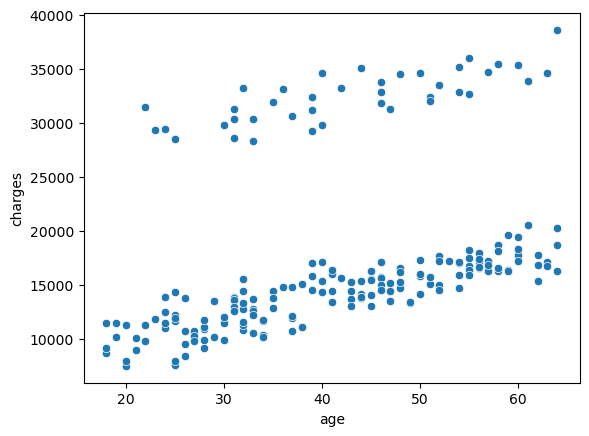

In [13]:
sns.scatterplot(x ="age", y= "charges", data = df)

In [14]:
df = pd.get_dummies(
    df,
    columns=['sex', 'smoker', 'region'],
    drop_first=True
)

### To check the strongest relationship with charges

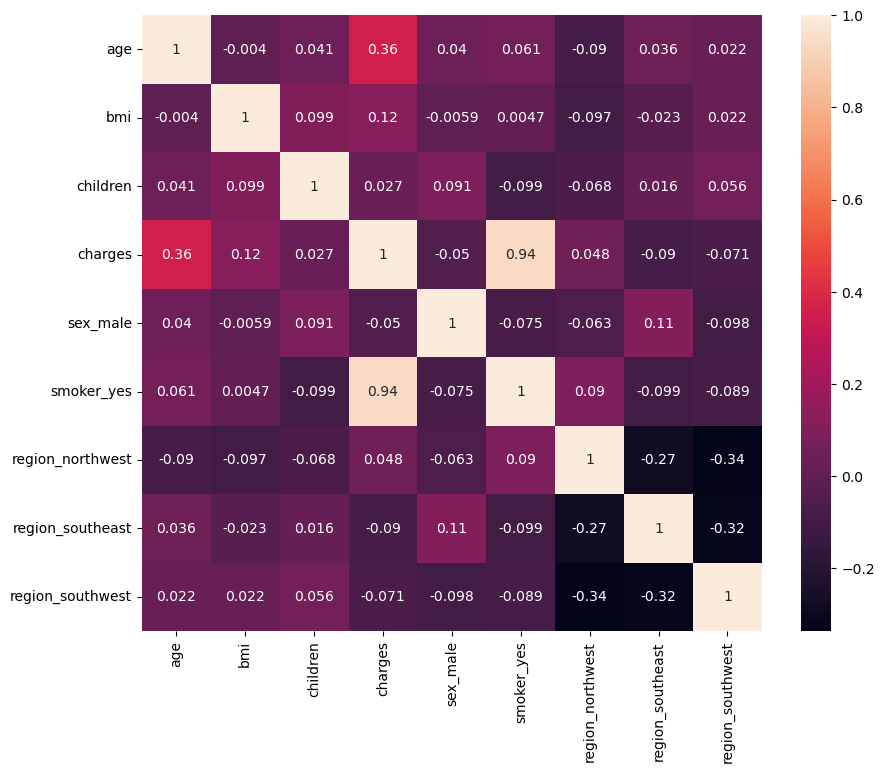

In [19]:
plt.figure(figsize = (10,8))
sns.heatmap(df_encoded.corr(), annot=True)
plt.show()

In [21]:
# Selecting x and y
X = df.drop("charges", axis=1)

In [25]:
y = df["charges"]

In [26]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
from sklearn.linear_model import LinearRegression

In [34]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [35]:
y_pred = model.predict(X_test)

In [36]:
print("MAE :", mean_absolute_error(y_test, y_pred))

MAE : 691.6971264643946


In [37]:
print("MSE :", mean_squared_error(y_test, y_pred))

MSE : 714076.9294383073


In [38]:
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))

RMSE : 845.0307269196235


In [39]:
print("R2 Score :", r2_score(y_test, y_pred))

R2 Score : 0.9833589221591088


In [40]:
# Comparing actual and predicted
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head()

,Actual,Predicted
95,10201.88,9496.802074
15,12220.30,12705.829290
30,11505.46,10282.093813
158,15855.15,15915.606202
128,13928.24,14290.222668


In [47]:
# Predicting a new customer's dataset
new_customer = pd.DataFrame({
    'age':[10],
    'bmi':[27.5],
    'children':[2],
    'sex_male':[1],
    'smoker_yes':[0],
    'region_northwest':[1],
    'region_southeast':[0],
    'region_southwest':[0]
})

In [48]:
prediction = model.predict(new_customer)

print(prediction)

[8074.19629529]


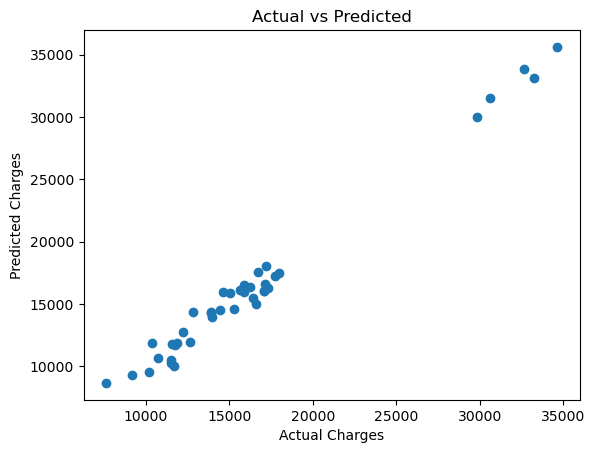

In [50]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted")
plt.show()